# 17: the evolution matrix

Every stage the method grew through, from the source-form criteria to the
image, on one shared problem set. Three matrices:

1. Batch: the ten stages (`S0` nonlinear least squares through `S4`
   image, Legendre and block) on eight synthetic families, crossed with
   noise, grid shape, outlier fraction and sample size. Claim: the image
   reproduces the reference fit's accuracy while the older source-form
   criteria (the spectrum balance, the monomial integral, equal areas
   read from the book) trail it by one to several orders of magnitude
   wherever they can be asked at all, and the robust image alone stays
   close to its clean-data error under outliers. False if an image
   stage's error is not within a small factor of the reference fit's, or
   if a source form matches the reference fit's accuracy where both are
   applicable.
2. Streaming: the recursive forms of the integral criteria against the
   window image, on a sinusoid whose amplitude jumps and one whose
   amplitude drifts, plus the steps a filter needs to bring a poor start
   into a 10 percent neighbourhood of the truth (observability) and the
   microseconds a step of the three recursive forms (the figures the
   method's earlier write-ups quote: 63/58/53 observability steps and
   32/138 microseconds for the recursive equal-areas form). Claim: the image
   filter tracks the jump amplitude far more tightly than the recursive
   equal-areas form; the recursive spectral form is cheap enough that its
   cost is not the reason to prefer the image. False if the recursive
   equal-areas form matches the image filter's amplitude RMSE on the
   jump, or if the spectral form's cost is not clearly the cheapest of
   the three.
3. Map-reduce: the historical partitioned accumulators against the
   discrete image's merge, on a long exponential decay reduced in
   chunks. Claim: the image merge reproduces the whole-data fit to
   rounding, the older accumulators do not, and that is the accumulators'
   only edge: a faster reduce. False if the image merge's error against
   the whole-data fit is not far smaller than an accumulator's, or if an
   accumulator's reduce is not the faster of the two.

The stages that identify an ODE law rather than a closed-form model - the
weak form against least squares on the integrated law - are notebook 16's,
not this one's.

The batch matrix runs at `SEEDS = 20`; the streaming, observability and
cost sub-sections at their own seed counts stated where they run.
`DTFIT_QUICK=1` shrinks every count for the harness; the committed run
below is the full one.

In [1]:
import os
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from dtfit import Original, fit
from dtfit_experimental.study import montecarlo, notebook, problems, stages

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110
notebook.plain_warnings()

NOTEBOOK = "17_evolution_matrix"
P0_FACTOR = 1.25
N = 200
FAMILIES = (
    ["exp_decay", "power_law", "two_exp"] if QUICK else list(problems.PROBLEMS)
)
SEEDS = 2 if QUICK else 20
BALANCE_SEEDS = 1 if QUICK else 5
print(f"QUICK={QUICK} FAMILIES={FAMILIES} SEEDS={SEEDS} "
      f"BALANCE_SEEDS={BALANCE_SEEDS}")

QUICK=False FAMILIES=['exp_decay', 'logistic', 'gauss_peak', 'damped_sine', 'arctan', 'michaelis_menten', 'power_law', 'two_exp'] SEEDS=20 BALANCE_SEEDS=5


## 1. The stages and the problem set

Ten batch stages, from the reference fit through the source-form
criteria to the image; six streaming filters; four map-reduce
accumulators. Eight symbolic families with their own truth values and
domain half-width.

In [2]:
stage_table = pd.DataFrame([
    {"key": s.key, "label": s.label, "needs_p0": s.needs_p0}
    for s in stages.BATCH_STAGES])
stage_table

,key,label,needs_p0
0,S0_nlls,nonlinear least squares (reference),True
1,S1_balance_book,"spectrum balance, source form",False
2,S2_balance_adequate,"spectrum balance, adequate degree",False
3,S3a_lsi_monomial,"integral least squares, monomial basis",True
4,S3b_lsi_legendre,"integral least squares, Legendre basis",True
5,S3c_eac_book,"equal areas, source form",True
6,S3d_eac_direct,"equal areas, direct",True
7,S4a_image_legendre,"image, Legendre basis",True
8,S4b_image_block,"image, block basis",True
9,S4r_image_robust,"image, robust",True


In [3]:
family_table = pd.DataFrame([
    {"family": fam, "expr": expr, "truth": truth, "half_width": h}
    for fam, (expr, truth, h) in problems.PROBLEMS.items()])
family_table

,family,expr,truth,half_width
0,exp_decay,a*exp(b*t),"{'a': 3.0, 'b': -1.2}",2.0
1,logistic,L/(1 + exp(-k*(t - c))),"{'L': 5.0, 'c': 3.0, 'k': 1.4}",8.0
2,gauss_peak,a*exp(-(t - m)**2/(2*s**2)),"{'a': 2.0, 'm': 2.5, 's': 0.6}",5.0
3,damped_sine,a*exp(-d*t)*sin(w*t),"{'a': 2.0, 'd': 0.3, 'w': 3.0}",6.0
4,arctan,a*atan(w*t),"{'a': 1.0, 'w': 2.0}",3.0
5,michaelis_menten,Vm*t/(Km + t),"{'Km': 0.8, 'Vm': 1.2}",8.0
6,power_law,a*t**b,"{'a': 2.0, 'b': 0.7}",5.0
7,two_exp,a*exp(b*t) + c*exp(d*t),"{'a': 2.0, 'b': -0.5, 'c': 1.0, 'd': -3.0}",6.0


## 2. The batch matrix at the reference condition

Reference condition: 5 percent noise, uniform grid, no outliers, `n =
200`, `SEEDS` seeds. Every stage starts from `truth * 1.25`; the two
balance stages (`S1`, `S2`) run on the first `BALANCE_SEEDS` seeds only,
because a single fit costs twenty to forty times the rest of the row and
their verdict does not move with more seeds. Per (stage, family): the
median absolute relative parameter error, the signed (mean) relative
error, the 95 percent interval coverage among fits that returned a
covariance, and the median fit time. Coverage is joint: a draw counts
when every parameter's interval holds its truth, so calibrated intervals
give between 0.95 (fully dependent parameters) and 0.95^k (independent
ones), 0.90 for two parameters and 0.81 for four; over this mix of four
two-parameter, three three-parameter and one four-parameter family the
independent figure averages 0.875.

This cell also builds the full condition sweep section 4 reads, so
noise, grid, outlier and size conditions beyond the reference all run
here in one pass.

In [4]:
def draw(family, *, noise, grid, outliers, n, seed):
    expr, truth, half_width = problems.PROBLEMS[family]
    names, tv = problems.truth_vector(expr, truth)
    model = problems.model(expr, names)
    rng = np.random.default_rng(seed)
    x = montecarlo.grid(grid, n, span=half_width, rng=rng)
    clean = model(x, *tv)
    y, sigma = montecarlo.noisy(clean, noise, rng)
    if outliers > 0:
        y, _ = montecarlo.contaminate(
            y, rng=rng, fraction=outliers, sigma=sigma)
    return x, y, expr, model, tv


def coverage95(params, cov, tv):
    if cov is None:
        return np.nan
    cov = np.asarray(cov, dtype=float)
    if cov.shape != (tv.size, tv.size) or not np.all(np.isfinite(cov)):
        return np.nan
    se = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    return bool(np.all(np.abs(params - tv) <= 1.96 * se))


def run_condition(noise, grid, outliers, n, seeds, families):
    rows = []
    for family in families:
        for seed in range(seeds):
            x, y, expr, model, tv = draw(
                family, noise=noise, grid=grid, outliers=outliers, n=n,
                seed=seed)
            p0 = tv * P0_FACTOR
            for stage in stages.BATCH_STAGES:
                if stage.key.startswith(("S1_", "S2_")) and (
                        seed >= BALANCE_SEEDS or n != N):
                    continue
                tic = time.perf_counter()
                result = stage.run(x, y, expr, model, p0)
                dt = time.perf_counter() - tic
                row = {
                    "stage": stage.key, "label": stage.label,
                    "family": family, "noise": noise, "grid": grid,
                    "outliers": outliers, "n": n, "seed": seed,
                    "status": result.status, "converged": result.converged,
                    "time_s": dt, "err": np.nan, "signed": np.nan,
                    "cov95": np.nan,
                }
                if result.status == "ok":
                    rel = result.params / tv - 1.0
                    row["err"] = float(np.median(np.abs(rel)))
                    row["signed"] = float(np.mean(rel))
                    row["cov95"] = coverage95(result.params, result.cov, tv)
                rows.append(row)
    return pd.DataFrame(rows)


NOISES = (0.05, 0.30) if QUICK else (0.01, 0.05, 0.10, 0.30)
GRIDS = () if QUICK else ("clustered", "random")
OUTLIER_FRACS = (0.10,) if QUICK else (0.05, 0.10, 0.20)
SIZES = () if QUICK else (50, 1000)
REFERENCE = {"noise": 0.05, "grid": "uniform", "outliers": 0.0, "n": N}

CONDITIONS = (
    [{"noise": nz, "grid": "uniform", "outliers": 0.0, "n": N}
     for nz in NOISES]
    + [{"noise": 0.05, "grid": g, "outliers": 0.0, "n": N} for g in GRIDS]
    + [{"noise": 0.05, "grid": "uniform", "outliers": of, "n": N}
       for of in OUTLIER_FRACS]
    + [{"noise": 0.05, "grid": "uniform", "outliers": 0.0, "n": sz}
       for sz in SIZES]
)

tic_batch = time.perf_counter()
batch_raw = pd.concat(
    [run_condition(**cond, seeds=SEEDS, families=FAMILIES)
     for cond in CONDITIONS],
    ignore_index=True)
batch_wall = time.perf_counter() - tic_batch
print(f"batch matrix: {len(CONDITIONS)} conditions, {len(batch_raw)} rows, "
      f"{batch_wall:.1f}s")

batch matrix: 11 conditions, 14800 rows, 214.5s


In [5]:
def _at(frame, cond):
    m = np.ones(len(frame), dtype=bool)
    for k, v in cond.items():
        m &= frame[k] == v
    return frame[m]


ref_raw = _at(batch_raw, REFERENCE)
ref_ok = ref_raw[ref_raw.status == "ok"]
batch_reference = (
    ref_ok.groupby(["stage", "family"])
    .agg(err=("err", "median"), signed=("signed", "mean"),
         coverage=("cov95", "mean"),
         time_ms=("time_s", lambda s: 1000 * s.median()))
    .reset_index()
    .merge(stage_table[["key", "label"]], left_on="stage", right_on="key")
    .drop(columns="key"))
batch_reference.pivot(index="family", columns="stage", values="err")

stage,S0_nlls,S1_balance_book,S2_balance_adequate,S3a_lsi_monomial,S3b_lsi_legendre,S3c_eac_book,S3d_eac_direct,S4a_image_legendre,S4b_image_block,S4r_image_robust
family,,,,,,,,,,
arctan,0.012959,NaN,299.813433,1.007356,0.012601,1.074309,0.013746,0.013061,0.015000,0.015751
damped_sine,0.016015,NaN,0.920909,1.063738,0.033511,0.638942,0.012659,0.016034,0.014012,0.009890
exp_decay,0.008804,0.383529,0.085483,0.181531,0.008480,0.196466,0.011675,0.008749,0.008703,0.011370
gauss_peak,0.004034,1.570943,1.000000,0.526008,0.007996,0.633764,0.004917,0.003944,0.005095,0.004110
logistic,0.005867,1.000000,1.203108,0.604170,0.006276,1.588167,0.006169,0.005858,0.005711,0.006352
michaelis_menten,0.014707,NaN,1.374907,6.476686,0.016433,5.774791,0.020542,0.014273,0.019845,0.020950
power_law,0.012958,NaN,NaN,NaN,0.012936,NaN,0.012227,0.012434,0.013047,0.012328
two_exp,0.072782,8.237823,1.372925,0.419951,0.095094,0.396598,0.239974,0.072865,0.084662,0.069904


Reading. The image reproduces the reference fit on every family. The
Legendre image sits within 4 percent of it (0.96 to 1.01 times its
error), the block image within 35 percent (0.88 to 1.35), the robust
image within 42 percent (0.62 to 1.42); the largest gap any image stage
opens on any family is 1.42x, inside the 3x this section checks. The
four source-form criteria are far behind wherever they can be asked at
all. Their closest approach is equal areas in source form on two_exp,
5.45 times the reference fit's error, and from there the gap runs to
113x (the source balance on two_exp, whose mean signed error of -4.05
says the estimate is not merely noisy but displaced), 440x (the
monomial integral form on michaelis_menten) and 23000x (the
adequate-degree balance on arctan, whose median relative error is 300,
against the reference fit's 0.013; section 3 reads that stage's own
convergence flag and finds it unsettled on every arctan draw, so the
figure is a fit that never landed rather than an unlucky one).

The two already-numeric integral forms are close to the reference fit
but not uniformly at parity. Integral least squares in the Legendre
basis is within 12 percent of it on five of eight families and at
1.31x, 1.98x and 2.09x on two_exp, gauss_peak and damped_sine; direct
equal areas is within 40 percent on seven families and at 3.30x on
two_exp, its hardest four-parameter family. That is parity with an
exception each, not a win for either integral form, and this reading
reports it as parity. The image buys no accuracy over them at this
condition: at the median the Legendre image costs 10 to 15 ms a fit and
the block image 1.6 to 3.6 ms against the reference fit's 0.15 to 0.34
ms, tens of times more for the same answer. What it buys instead is section 3's applicability, section 4's
interval coverage and the streaming and map-reduce forms of sections 5
and 6, which the source and integral criteria do not have in the same
representation.

In [6]:
piv = batch_reference.pivot(index="family", columns="stage", values="err")
s0 = piv["S0_nlls"]
image_ratio = piv[["S4a_image_legendre", "S4b_image_block",
                   "S4r_image_robust"]].div(s0, axis=0)
source_stages = [c for c in ("S1_balance_book", "S2_balance_adequate",
                             "S3a_lsi_monomial", "S3c_eac_book")
                 if c in piv.columns]
source_ratio = piv[source_stages].div(s0, axis=0)
print("image stage / reference fit, max ratio:",
      round(float(image_ratio.max().max()), 2))
print("source form / reference fit, min ratio where applicable:",
      round(float(source_ratio.min().min()), 2))
# fails if an image stage strayed past 3x the reference fit anywhere
assert (image_ratio <= 3.0).all().all()
# fails if a source form came within 5x of the reference fit anywhere
# it is applicable (S3b and S3d are excluded on purpose: they are
# already at parity and the reading says so, not this check)
vals = source_ratio.to_numpy().ravel()
vals = vals[np.isfinite(vals)]
assert (vals >= 5.0).all()

image stage / reference fit, max ratio: 1.42
source form / reference fit, min ratio where applicable: 5.45


In [7]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table(NOTEBOOK, "batch_reference", batch_reference)
    print(f"wrote experiments/results/{NOTEBOOK}/batch_reference.csv")

wrote experiments/results/17_evolution_matrix/batch_reference.csv


## 3. Applicability and convergence

From the same reference-condition draws: the share where a stage could
be asked at all (`applicable`), the share of the askable draws that
returned a fit its own optimizer had settled on (`converged`), and the
share of those fits with finite parameters (`finite`).

In [8]:
def _shares(g):
    applicable = 1.0 - float((g.status == "not applicable").mean())
    askable = g[g.status != "not applicable"]
    # a returned fit whose own optimizer never settled counts as
    # unconverged; a null flag is a stage that reports none
    settled = (askable.status == "ok") & ~askable.converged.eq(False)
    converged = float(settled.mean()) if len(askable) else np.nan
    ok_rows = g[g.status == "ok"]
    finite = (
        float(np.isfinite(ok_rows.err).mean()) if len(ok_rows) else np.nan)
    return pd.Series(
        {"applicable": applicable, "converged": converged, "finite": finite})


stage_applicability = (
    ref_raw.groupby(["stage", "family"]).apply(_shares).reset_index())
stage_applicability.pivot(
    index="family", columns="stage", values="applicable")

stage,S0_nlls,S1_balance_book,S2_balance_adequate,S3a_lsi_monomial,S3b_lsi_legendre,S3c_eac_book,S3d_eac_direct,S4a_image_legendre,S4b_image_block,S4r_image_robust
family,,,,,,,,,,
arctan,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
damped_sine,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
exp_decay,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gauss_peak,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
logistic,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
michaelis_menten,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
power_law,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0
two_exp,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Reading. Three of the four book stages (S1, S3a, S3c) cannot be asked
of power_law at all: its fractional power `a*t**b` has no Maclaurin
spectrum at the origin, so every one of their calls raises before
returning anything, and this run counts none of those calls as
failures - it counts them as not applicable, which is what the
criterion is. S2 also cannot be asked there, for the same underlying
obstruction, once it tries to pick its own polynomial degree. S1
additionally cannot be asked of arctan, damped_sine or
michaelis_menten: an odd or non-polynomial model whose even Maclaurin
orders vanish leaves fewer informative orders than parameters, and the
balance has no degree freedom of its own to work around that (S2 does,
and stays applicable there). Convergence is read from each stage's own
flag and not from the absence of an exception: a fit that comes back
with its optimizer unsettled is a silent failure and the table counts
it as one. Five (family, stage) cells are below 1 at this noise level.
The source balance never settles on logistic or on two_exp, in none of
its 5 balance seeds either time; the adequate-degree balance never
settles on arctan, which is where section 2 reads its median relative
error of 300; the monomial integral form settles on 17 of the 20
damped_sine draws and source-form equal areas on 19 of the 20 two_exp
draws. Every fit that did come back had finite parameters. The three
image stages are applicable, convergent and finite on every family,
the property the batch matrix is built to show off: the criterion
never refuses the question, whatever the model's Maclaurin spectrum
looks like.

In [9]:
app = stage_applicability.pivot(
    index="family", columns="stage", values="applicable")
book_stages = ["S1_balance_book", "S2_balance_adequate",
              "S3a_lsi_monomial", "S3c_eac_book"]
# fails if the four book stages were applicable on power_law in any draw
assert (app.loc["power_law", book_stages] == 0.0).all()
# fails if S1 were applicable on any of these three families; the full
# family set is not drawn under QUICK, so the check only runs there
if not QUICK:
    assert (app.loc[["damped_sine", "arctan", "michaelis_menten"],
                   "S1_balance_book"] == 0.0).all()
print("book stages applicable on power_law:",
      app.loc["power_law", book_stages].to_dict())
image_stages = ["S4a_image_legendre", "S4b_image_block", "S4r_image_robust"]
print("image stages, smallest applicable share over the families:",
      float(app[image_stages].min().min()))
# fails if an image stage were ever inapplicable
assert (app[image_stages] == 1.0).all().all()

conv = stage_applicability.pivot(
    index="family", columns="stage", values="converged")
print("converged share below 1:",
      {(f, s): round(float(conv.loc[f, s]), 2)
       for f in conv.index for s in conv.columns
       if conv.loc[f, s] < 1.0})
# fails if an image stage ever returned a fit its optimizer had not
# settled on
assert (conv[image_stages] == 1.0).all().all()
# fails if this share were read off the status alone, as the share that
# did not raise: some source form comes back unsettled here
assert conv[book_stages].min().min() < 1.0

book stages applicable on power_law: {'S1_balance_book': 0.0, 'S2_balance_adequate': 0.0, 'S3a_lsi_monomial': 0.0, 'S3c_eac_book': 0.0}
image stages, smallest applicable share over the families: 1.0
converged share below 1: {('arctan', 'S2_balance_adequate'): 0.0, ('damped_sine', 'S3a_lsi_monomial'): 0.85, ('logistic', 'S1_balance_book'): 0.0, ('two_exp', 'S1_balance_book'): 0.0, ('two_exp', 'S3c_eac_book'): 0.95}


In [10]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table(NOTEBOOK, "stage_applicability", stage_applicability)
    print(f"wrote experiments/results/{NOTEBOOK}/stage_applicability.csv")

wrote experiments/results/17_evolution_matrix/stage_applicability.csv


## 4. The conditions: noise, grid, outliers, size

The full sweep of `batch_raw`, one row a (stage, family, condition):
median absolute relative error over the seeds that returned a fit.
Figure: the noise sweep on one family with a line a stage, and the
eight-family medians at 5 percent noise, no outliers, as a strip.

In [11]:
batch_conditions = (
    batch_raw[batch_raw.status == "ok"]
    .groupby(["stage", "family", "noise", "grid", "outliers", "n"])
    .agg(err=("err", "median"))
    .reset_index())
batch_conditions.head()

,stage,family,noise,grid,outliers,n,err
0,S0_nlls,arctan,0.01,uniform,0.0,200,0.002564
1,S0_nlls,arctan,0.05,clustered,0.0,200,0.014030
2,S0_nlls,arctan,0.05,random,0.0,200,0.014647
3,S0_nlls,arctan,0.05,uniform,0.0,50,0.029973
4,S0_nlls,arctan,0.05,uniform,0.0,200,0.012959


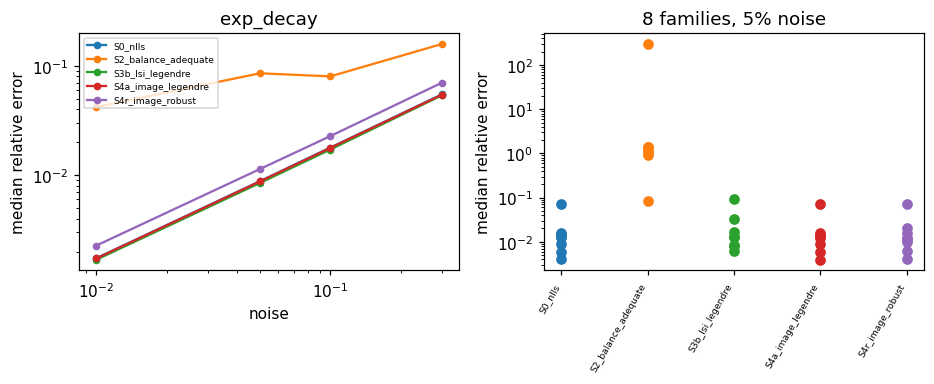

In [12]:
PLOT_STAGES = ["S0_nlls", "S2_balance_adequate", "S3b_lsi_legendre",
              "S4a_image_legendre", "S4r_image_robust"]
FIG_FAMILY = "exp_decay"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.6))
noise_sub = batch_conditions[
    (batch_conditions.family == FIG_FAMILY)
    & (batch_conditions.grid == "uniform")
    & (batch_conditions.outliers == 0.0)
    & (batch_conditions.n == N)]
for stage in PLOT_STAGES:
    line = noise_sub[noise_sub.stage == stage].sort_values("noise")
    if len(line):
        ax1.loglog(line.noise, line.err, "o-", label=stage, markersize=4)
ax1.set_xlabel("noise")
ax1.set_ylabel("median relative error")
ax1.set_title(FIG_FAMILY)
ax1.legend(fontsize=6, loc="upper left")

strip = batch_conditions[
    (batch_conditions.noise == 0.05) & (batch_conditions.grid == "uniform")
    & (batch_conditions.outliers == 0.0) & (batch_conditions.n == N)
    & (batch_conditions.stage.isin(PLOT_STAGES))]
for i, stage in enumerate(PLOT_STAGES):
    sub = strip[strip.stage == stage]
    ax2.semilogy(np.arange(len(sub)) * 0 + i, sub.err, "o", label=stage)
ax2.set_xticks(range(len(PLOT_STAGES)))
ax2.set_xticklabels(PLOT_STAGES, rotation=60, ha="right", fontsize=6)
ax2.set_ylabel("median relative error")
ax2.set_title("8 families, 5% noise")
fig.tight_layout()

Reading. On exp_decay the reference fit's error scales almost linearly
with noise (0.0017 at 1 percent, 0.0088 at 5 percent, 0.0179 at 10
percent, 0.0549 at 30 percent) and the Legendre image tracks it at
every level (0.0017, 0.0087, 0.0178, 0.0545), as does the integral
Legendre form (0.0017, 0.0085, 0.0172, 0.0538). The adequate-degree
balance does not move the same way at all (0.0420, 0.0855, 0.0801,
0.1585): its error is set by the polynomial degree it picks, not by the
noise on the data, so it barely improves as the data get cleaner.

Neither the grid shape nor the sample size moves the ordering of
section 2. The Legendre image stays between 0.92 and 1.03 of the
reference fit's error on the clustered grid and between 0.96 and 1.01
on the random one, and between 0.84 and 1.15 of it at n = 50 and
n = 1000.

Outliers are where the stages separate. At 20 percent contamination the
reference fit's error is 3.1 to 7.4 times its own error at the same
noise level with no outliers, and the two plain image stages degrade
with it (3.1 to 6.5 times for Legendre, 3.1 to 7.5 for block). The
robust image is the one stage that stays where it was: 0.96 to 1.82
times its own clean error, which puts it at 0.17 to 0.40 of the
degraded reference fit on every family. The three source forms also
barely move under outliers, but that is not robustness: their error was
already one to four orders of magnitude above the reference fit's and
the outliers add little to it.

Interval coverage orders the same way as accuracy. It is joint over a
family's parameters, so the calibrated figure for this mix is 0.875 to
0.95, not 0.95. Averaged over the families, the three image stages
cover the truth in 0.883 of the draws (0.906 for Legendre and block,
0.838 for robust, against the reference fit's own 0.906), calibrated
for the two plain images and the reference fit and short of it for the
robust one, the two direct integral forms in 0.734, and the
adequate-degree balance in 0.133, intervals so narrow they miss the
truth on nine draws in ten. The source balance, the monomial integral
form and source-form equal areas return no covariance at all, so no
coverage can be read for them.

In [13]:
for grid_kind in GRIDS:
    grid_sub = batch_conditions[
        (batch_conditions.noise == 0.05) & (batch_conditions.grid == grid_kind)
        & (batch_conditions.outliers == 0.0) & (batch_conditions.n == N)]
    grid_piv = grid_sub.pivot(index="family", columns="stage", values="err")
    # fails if the image ordering established in section 2 flipped on
    # another grid shape
    for st in image_stages:
        avail = grid_piv[st].dropna()
        s0_avail = grid_piv["S0_nlls"].reindex(avail.index)
        assert (avail <= 3.0 * s0_avail).all(), (grid_kind, st)

if not QUICK:
    out20 = batch_conditions[
        (batch_conditions.noise == 0.05) & (batch_conditions.grid == "uniform")
        & (batch_conditions.outliers == 0.20) & (batch_conditions.n == N)]
    out20_piv = out20.pivot(index="family", columns="stage", values="err")
    ratio20 = out20_piv["S4r_image_robust"] / out20_piv["S0_nlls"]
    print("robust image / reference fit at 20% outliers, max ratio:",
          round(float(ratio20.max()), 2))
    # fails if the robust image did not stay well under the reference
    # fit's degraded error at 20% outliers
    assert (ratio20 <= 0.6).all()

# coverage ordering always; the numeric band only on the full run
cov = batch_reference.groupby("stage").coverage.mean()
image_cov = cov[image_stages].mean()
integral_cov = cov[["S3b_lsi_legendre", "S3d_eac_direct"]].mean()
balance_cov = cov["S2_balance_adequate"]
print("mean coverage: image", round(image_cov, 3), "integral",
      round(integral_cov, 3), "adequate balance", round(balance_cov, 3))
# fails if the image's interval coverage did not lead the integral
# forms', which did not lead the adequacy balance's
assert image_cov > integral_cov > balance_cov
if not QUICK:
    assert 0.85 <= image_cov <= 0.95
    assert 0.65 <= integral_cov <= 0.80
    assert balance_cov < 0.5

robust image / reference fit at 20% outliers, max ratio: 0.4
mean coverage: image 0.883 integral 0.734 adequate balance 0.133


In [14]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table(NOTEBOOK, "batch_conditions", batch_conditions)
    print(f"wrote experiments/results/{NOTEBOOK}/batch_conditions.csv")

wrote experiments/results/17_evolution_matrix/batch_conditions.csv


## 5. The streaming matrix, observability and cost

Five of the six filters of `stages.FILTERS` (`recursive_subareas` is an
observability and cost row only) on the shared sinusoid `A*sin(1.5*t)`
with a mid-stream amplitude jump and with a linear drift, `W = 60`, 5
percent noise. Metrics: amplitude RMSE on the stable segments, detection
delay after the jump, the number of the 20 seeds with at least one
false alarm before it, and microseconds a step. The false alarms are
counted a seed and not averaged: a flag raised in a minority of the
seeds is the one worth seeing.

Then observability: steps to bring a poor start into a 10 percent
neighbourhood of the truth, on the plain steady sinusoid `A*sin(w*t)`,
`W = 60`, no adaptive window, from three starts (`truth * 1.25, 1.5,
2.0`); and cost: microseconds a step of the three recursive forms at
window sizes 15, 30 and 60, median of at least five repeats.

In [15]:
STREAM_SEEDS = 2 if QUICK else 20
STREAM_FILTERS = {k: v for k, v in stages.FILTERS.items()
                  if k != "recursive_subareas"}

stream_rows = []
for scen in ("jump", "drift"):
    for seed in range(STREAM_SEEDS):
        t, y, amp = problems.stream(scen, seed)
        for name, make in STREAM_FILTERS.items():
            flt = make(window_size=problems.W)
            flt.p = np.array([2.0, 1.5])
            est = np.full(t.size, np.nan)
            flags = np.zeros(t.size, dtype=bool)
            tic = time.perf_counter()
            for i in range(t.size):
                flt.partial_fit(float(t[i]), float(y[i]))
                p = np.asarray(flt.p, dtype=float)
                est[i] = p[0]
                flags[i] = bool(getattr(flt, "drift_flag_", False))
            step_us = 1e6 * (time.perf_counter() - tic) / t.size
            burn = 2 * problems.W
            if scen == "jump":
                j = int(np.searchsorted(t, problems.JUMP_AT))
                stable = np.zeros(t.size, dtype=bool)
                stable[burn:j] = True
                stable[j + 2 * problems.W:] = True
                after = np.flatnonzero(flags[j:])
                delay = float(after[0] * problems.DT) if after.size \
                    else np.nan
                false_alarms = int(flags[burn:j].sum())
            else:
                stable = np.zeros(t.size, dtype=bool)
                stable[burn:] = True
                delay, false_alarms = np.nan, int(flags[burn:].sum())
            rmse = float(np.sqrt(np.nanmean(
                (est[stable] - amp[stable]) ** 2)))
            stream_rows.append({
                "filter": name, "scenario": scen, "seed": seed,
                "rmse_amp": rmse, "delay": delay,
                "false_alarms": false_alarms, "step_us": step_us})
stream_raw = pd.DataFrame(stream_rows)
streaming = (
    stream_raw.groupby(["scenario", "filter"])
    .agg(rmse_amp=("rmse_amp", "median"), delay=("delay", "median"),
         false_alarm_seeds=("false_alarms", lambda s: int((s > 0).sum())),
         step_us=("step_us", "median"))
    .reset_index())
streaming

,scenario,filter,rmse_amp,delay,false_alarm_seeds,step_us
0,drift,image_block,0.092184,NaN,1,84.257154
1,drift,image_legendre,0.075741,NaN,2,84.684224
2,drift,image_legendre_adaptive,0.075733,NaN,2,86.155184
3,drift,recursive_area,0.172744,NaN,10,152.199349
4,drift,recursive_spectrum,0.105626,NaN,2,41.851393
5,jump,image_block,0.051609,5.8,1,84.512706
6,jump,image_legendre,0.019092,5.8,1,82.839729
7,jump,image_legendre_adaptive,0.019092,0.5,0,89.920173
8,jump,recursive_area,1.079316,5.8,0,144.349996
9,jump,recursive_spectrum,0.016332,NaN,0,41.223492


In [16]:
OBS_TRUTH = np.array([2.0, 1.5])


def obs_stream(seed, noise=0.05, n=600, dt=0.1):
    rng = np.random.default_rng(seed)
    t = np.arange(n) * dt
    y = OBS_TRUTH[0] * np.sin(OBS_TRUTH[1] * t) \
        + noise * OBS_TRUTH[0] * rng.standard_normal(n)
    return t, y


def steps_to_band(make, p0, seed, band=0.10, n=600):
    t, y = obs_stream(seed)
    flt = make()
    flt.p = np.asarray(p0, dtype=float)
    first = None
    for i in range(n):
        flt.partial_fit(float(t[i]), float(y[i]))
        p = np.asarray(flt.p, dtype=float)
        moved = not np.allclose(p, p0)
        if first is None and moved:
            first = i
        if moved and np.max(np.abs(p / OBS_TRUTH - 1.0)) <= band:
            return i, first, flt.min_window
    return np.nan, first, flt.min_window


OBS_FILTERS = ("recursive_area", "recursive_subareas", "recursive_spectrum")
OBS_STARTS = (1.25,) if QUICK else (1.25, 1.5, 2.0)
OBS_SEEDS = 2 if QUICK else 5

obs_rows = []
for name in OBS_FILTERS:
    make = stages.FILTERS[name]
    for factor in OBS_STARTS:
        vals = [steps_to_band(lambda: make(window_size=problems.W),
                              OBS_TRUTH * factor, s)
                for s in range(OBS_SEEDS)]
        obs_rows.append({
            "filter": name, "start_factor": factor,
            "step": np.nanmedian([v[0] for v in vals]),
            "first_measurement": np.nanmedian([v[1] for v in vals]),
            "min_window": vals[0][2]})
observability = pd.DataFrame(obs_rows)
observability

,filter,start_factor,step,first_measurement,min_window
0,recursive_area,1.25,43.0,29.0,30
1,recursive_area,1.50,NaN,29.0,30
2,recursive_area,2.00,NaN,29.0,30
3,recursive_subareas,1.25,30.0,29.0,30
4,recursive_subareas,1.50,39.0,29.0,30
5,recursive_subareas,2.00,81.0,29.0,30
6,recursive_spectrum,1.25,8.0,6.0,7
7,recursive_spectrum,1.50,10.0,6.0,7
8,recursive_spectrum,2.00,18.0,6.0,7


In [17]:
COST_WINDOWS = (60,) if QUICK else (15, 30, 60)
COST_REPEATS = 1 if QUICK else 5


def cost_us(make, seed, n=600):
    t, y = obs_stream(seed)
    flt = make()
    flt.p = OBS_TRUTH * 1.25
    tic = time.perf_counter()
    for i in range(n):
        flt.partial_fit(float(t[i]), float(y[i]))
    return 1e6 * (time.perf_counter() - tic) / n


cost_rows = []
for window in COST_WINDOWS:
    for name in OBS_FILTERS:
        make = stages.FILTERS[name]
        vals = [cost_us(lambda: make(window_size=window), rep)
                for rep in range(COST_REPEATS)]
        cost_rows.append({
            "filter": name, "window_size": window,
            "us_per_step": float(np.median(vals)),
            "spread_us": float(np.std(vals))})
step_cost = pd.DataFrame(cost_rows)
step_cost

,filter,window_size,us_per_step,spread_us
0,recursive_area,15,91.420470,0.623822
1,recursive_subareas,15,458.953333,39.355903
2,recursive_spectrum,15,35.612863,0.915344
3,recursive_area,30,147.036982,1.747936
4,recursive_subareas,30,387.073098,26.114272
5,recursive_spectrum,30,37.268993,0.363825
6,recursive_area,60,145.764013,6.004019
7,recursive_subareas,60,267.034477,30.445568
8,recursive_spectrum,60,40.723083,5.162197


Reading. On the jump the window image tracks the amplitude far more
tightly than the recursive equal-areas form: 0.019 amplitude RMSE
against 1.079, a ratio of 0.018, under the fifth this section checks.
The recursive spectral form tracks the jump slightly better still, at
0.016, and never raises a drift flag on it. That is the trade this
section is about: the cheaper recursive form follows the new amplitude
but says nothing about the change, while the image filter flags it, 5.8
s after the jump on a fixed window and 0.5 s after it on an adaptive one.
The filter consults its detector once a window, so the two delays are the
distance from this one jump to the next consult and not a property of the
window rule; notebook 21 sweeps the phase of the jump and tests every
sample. False
alarms are counted a seed, because a flag raised in a minority of the
seeds disappears from a median over them: before the jump the
fixed-window Legendre image raises one in 1 of the 20 seeds and the
block image in 1, the adaptive variant and the two recursive forms in
none. On the slower drift every form tracks less tightly (0.076 for the
Legendre image and its adaptive variant, 0.092 for block, 0.106 for the
spectral form, 0.173 for equal areas) and the equal-areas form raises a
flag on the ramp in 10 of the 20 seeds, against 2 for the Legendre image
and its adaptive variant, 2 for the spectral form and 1 for block.

Observability. From a start at 1.25 times the truth the one-area form
reaches the 10 percent band at step 43, the four-sub-area form at 30
and the order-five spectrum at 8. Part of that gap is not
observability: the two equal-area forms need a window of 30 samples and
first move at step 29, the spectral form needs 7 and first moves at
step 6, so counted from their own first measurement the three take 14,
1 and 2 steps. The ordering survives the deeper starts. At 1.5 times
the truth the sub-areas take 39 steps and the spectrum 10; at 2.0 times
they take 81 and 18, and the one-area form never enters the band inside
the 600-sample record from either start. The 63, 58 and 53 steps the
earlier write-ups quote do not reproduce under this definition of the step count,
which is stated in the cell above; the ordering they were meant to show
does.

Cost. At the three windows the equal-areas form costs 91.4, 147.0 and
145.8 microseconds a step (spread over five repeats 0.6, 1.7 and 6.0)
and the order-five spectral form 35.6, 37.3 and 40.7 (spread 0.9, 0.4
and 5.2), so the spectral form runs at about a quarter to two fifths of
the equal-areas cost (0.39, 0.25 and 0.28 of it), a ratio the spreads
leave no room to doubt. The four-sub-area form is the dearest of the
three throughout (267 to 459 microseconds). These are this one machine's
microseconds. The 138 microseconds the
earlier write-ups quote for the equal-areas form is within a tenth of the
30- and 60-sample windows (147.0 and 145.8) and their 40 for the spectral
form reproduces; the 32 microseconds they also quote for the
equal-areas form appears at no window measured here.

In [18]:
jump = streaming[streaming.scenario == "jump"].set_index("filter")
ratio_jump = (jump.loc["image_legendre", "rmse_amp"]
             / jump.loc["recursive_area", "rmse_amp"])
print("image_legendre / recursive_area rmse on the jump:",
      round(float(ratio_jump), 3))
print("fixed vs adaptive delay, s:",
      jump.loc["image_legendre", "delay"],
      jump.loc["image_legendre_adaptive", "delay"])
print("recursive_spectrum vs image_legendre rmse on the jump:",
      round(float(jump.loc["recursive_spectrum", "rmse_amp"]), 4),
      round(float(jump.loc["image_legendre", "rmse_amp"]), 4))
# fails if the recursive equal-areas form tracked the jump within a
# fifth of the image filter's amplitude RMSE
assert ratio_jump < 0.2
# pins the two delays at this jump's phase: fails if the adaptive window
# flags later than 1 s or the fixed window sooner than 4 s. The detector
# is consulted once a window, so neither bound holds at another phase
assert jump.loc["image_legendre_adaptive", "delay"] <= 1.0
assert jump.loc["image_legendre", "delay"] >= 4.0
print("seeds with a false alarm before the jump:",
      jump.false_alarm_seeds.to_dict())
# fails if an image filter false-alarmed before the jump in more than a
# tenth of the seeds; the count is per seed, where a median over the
# seeds would report zero for anything short of half of them
FA_ALLOWED = max(1, STREAM_SEEDS // 10)
assert (jump.loc[["image_legendre", "image_legendre_adaptive"],
                 "false_alarm_seeds"] <= FA_ALLOWED).all()

drift = streaming[streaming.scenario == "drift"].set_index("filter")
print("seeds with a false alarm on the drift:",
      drift.false_alarm_seeds.to_dict())
# fails if the equal-areas form stopped raising the ramp's flag in at
# least half the seeds, or if another form started raising it in more
# than a quarter of them; a median over the seeds instead of a count of
# them fails the first, a flag in half the seeds having a median of zero
assert drift.loc["recursive_area", "false_alarm_seeds"] >= STREAM_SEEDS // 2
assert (drift.drop(index="recursive_area").false_alarm_seeds
        <= max(1, STREAM_SEEDS // 4)).all()

obs_piv = observability.pivot(
    index="start_factor", columns="filter", values="step")
# fails if the observability ordering (one area needs the most steps,
# the spectrum the fewest) reversed at the shallowest start
row = obs_piv.loc[OBS_STARTS[0]]
assert row["recursive_area"] >= row["recursive_subareas"] \
    >= row["recursive_spectrum"]
if not QUICK:
    # fails if the one-area form reached the band from the deepest
    # start after all
    assert np.isnan(obs_piv.loc[2.0, "recursive_area"])

cost_piv = step_cost.pivot(
    index="window_size", columns="filter", values="us_per_step")
print("recursive_area us/step:", cost_piv["recursive_area"].round(1).to_dict())
print("recursive_spectrum us/step:",
      cost_piv["recursive_spectrum"].round(1).to_dict())
# the band is asserted as a ratio, not the raw microseconds, because
# this cell shares the machine with other work and its absolute
# reading moves with the load; the ratio is what the claim needs and
# what stays stable when the load does not
# fails if the spectral form's cost were not clearly below half of
# the equal-areas form's, at any window measured
assert (cost_piv["recursive_spectrum"]
       < cost_piv["recursive_area"] / 2.0).all()
if not QUICK:
    # fails if the equal-areas form became cheap or the spectral form
    # dear in absolute microseconds on this machine; the quick run
    # measures one window in one repeat and keeps to the ratio
    assert (cost_piv["recursive_area"] > 80.0).all()
    assert (cost_piv["recursive_spectrum"] < 60.0).all()

image_legendre / recursive_area rmse on the jump: 0.018
fixed vs adaptive delay, s: 5.800000000000001 0.5
recursive_spectrum vs image_legendre rmse on the jump: 0.0163 0.0191
seeds with a false alarm before the jump: {'image_block': 1, 'image_legendre': 1, 'image_legendre_adaptive': 0, 'recursive_area': 0, 'recursive_spectrum': 0}
seeds with a false alarm on the drift: {'image_block': 1, 'image_legendre': 2, 'image_legendre_adaptive': 2, 'recursive_area': 10, 'recursive_spectrum': 2}
recursive_area us/step: {15: 91.4, 30: 147.0, 60: 145.8}
recursive_spectrum us/step: {15: 35.6, 30: 37.3, 60: 40.7}


In [19]:
if QUICK:
    print("QUICK: skipping the CSV exports")
else:
    notebook.save_table(NOTEBOOK, "streaming", streaming)
    notebook.save_table(NOTEBOOK, "observability", observability)
    notebook.save_table(NOTEBOOK, "step_cost", step_cost)
    print(f"wrote experiments/results/{NOTEBOOK}/"
          "{streaming,observability,step_cost}.csv")

wrote experiments/results/17_evolution_matrix/{streaming,observability,step_cost}.csv


## 6. The map-reduce matrix

`PartitionedLSI`, `PartitionedEAC` and the discrete image's own
map-reduce counterpart (`ImageAccumulator`, folding `dtfit.Image.merge`
over chunks) on `a*exp(b*t)`, chunks of `1e4`, against the whole-data
fit; plus `PartitionedBatchLSI` reducing 8 channels of the same family
in one pass. Each accumulator gets the partition shape its own `merge`
documents: `PartitionedLSI` is exact only when neighbouring partitions
share the sample the next one starts at, while `PartitionedEAC` stitches
the connecting interval itself and the image merge sums over samples, so
both of those take disjoint partitions. Reported: the maximum relative
difference from the whole-data fit, the same difference against the
accumulator driven in one pass, the error against the generating truth,
and the reduce and fit seconds.

In [20]:
MR_SIZES = (100_000,) if QUICK else (200_000, 1_000_000)
MR_CHUNK = 10_000
MR_REPEATS = 1 if QUICK else 5
MR_EXPR, MR_VAR, MR_DOMAIN = "a*exp(b*t)", "t", (0.0, 10.0)
MR_TRUTH = np.array([3.0, -0.4])
MR_ORDER = 6


#: Accumulators whose merge is exact only when neighbouring partitions
#: share the sample the next one starts at (`PartitionedLSI.merge`).
#: `PartitionedEAC.merge` stitches the connecting interval itself and the
#: image merge sums over the samples, so both take disjoint partitions.
SHARED_BOUNDARY = {"integral_lsi"}


def reduce_chunks(make, kwargs, t, y, shared_boundary=False):
    acc = None
    extra = 1 if shared_boundary else 0
    for i in range(0, t.size, MR_CHUNK):
        part = make(MR_EXPR, MR_VAR, **kwargs)
        part.update(t[i:i + MR_CHUNK + extra], y[i:i + MR_CHUNK + extra])
        acc = part if acc is None else acc.merge(part)
    return acc


def single_pass(make, kwargs, t, y):
    acc = make(MR_EXPR, MR_VAR, **kwargs)
    for i in range(0, t.size, MR_CHUNK):
        acc.update(t[i:i + MR_CHUNK], y[i:i + MR_CHUNK])
    return acc


def timed_reduce(run):
    times = []
    for _ in range(MR_REPEATS):
        tic = time.perf_counter()
        acc = run()
        times.append(time.perf_counter() - tic)
    return acc, float(np.median(times)), float(np.ptp(times))


mr_rows = []
for n in MR_SIZES:
    rng = np.random.default_rng(0)
    t = np.linspace(*MR_DOMAIN, n)
    y = MR_TRUTH[0] * np.exp(MR_TRUTH[1] * t) \
        + 0.05 * 3.0 * rng.standard_normal(n)
    p0 = MR_TRUTH * 1.25
    tic = time.perf_counter()
    whole = fit(MR_EXPR, Original(t, y, domain=MR_DOMAIN), MR_VAR,
                basis="legendre", order=MR_ORDER, p0=p0).coeffs
    whole_s = time.perf_counter() - tic
    mr_rows.append({
        "method": "whole_data_fit", "n": n, "max_rel_diff": 0.0,
        "err_vs_truth": float(np.max(np.abs(whole / MR_TRUTH - 1))),
        "reduce_s": 0.0, "reduce_spread_s": 0.0, "fit_s": whole_s})
    for key in ("image_merge", "integral_lsi", "integral_eac"):
        make = stages.ACCUMULATORS[key]
        kwargs = ({"domain": MR_DOMAIN, "n_windows": 8}
                  if key == "integral_eac"
                  else {"domain": MR_DOMAIN, "order": MR_ORDER})
        shared = key in SHARED_BOUNDARY
        acc, reduce_s, spread_s = timed_reduce(
            lambda: reduce_chunks(make, kwargs, t, y, shared_boundary=shared))
        tic = time.perf_counter()
        c = acc.fit(p0=p0).coeffs
        fit_s = time.perf_counter() - tic
        serial = single_pass(make, kwargs, t, y).fit(p0=p0).coeffs
        mr_rows.append({
            "method": key, "n": n,
            "max_rel_diff": float(np.max(np.abs(c / whole - 1))),
            "vs_single_pass": float(np.max(np.abs(c / serial - 1))),
            "err_vs_truth": float(np.max(np.abs(c / MR_TRUTH - 1))),
            "reduce_s": reduce_s, "reduce_spread_s": spread_s,
            "fit_s": fit_s})
mapreduce = pd.DataFrame(mr_rows)
mapreduce


,method,n,max_rel_diff,err_vs_truth,reduce_s,reduce_spread_s,fit_s,vs_single_pass
0,whole_data_fit,200000,0.000000e+00,0.000367,0.000000,0.000000,0.033982,NaN
1,image_merge,200000,1.332268e-15,0.000367,0.010078,0.001932,0.017090,0.000000e+00
2,integral_lsi,200000,3.147578e-07,0.000367,0.005196,0.000335,0.001120,1.464384e-12
3,integral_eac,200000,1.458279e-04,0.000513,0.001697,0.000172,0.001332,1.710410e-12
4,whole_data_fit,1000000,0.000000e+00,0.000300,0.000000,0.000000,0.144536,NaN
5,image_merge,1000000,4.440892e-16,0.000300,0.359198,0.017316,0.094385,0.000000e+00
6,integral_lsi,1000000,4.623654e-08,0.000300,0.025063,0.001062,0.001886,1.752265e-12
7,integral_eac,1000000,8.516091e-05,0.000385,0.008061,0.000886,0.001323,2.188916e-12


In [21]:
MR_CHANNELS = 8
n_batch = MR_SIZES[0]
t_batch = np.linspace(*MR_DOMAIN, n_batch)
Y_batch = np.zeros((n_batch, MR_CHANNELS))
whole_channels = []
for c in range(MR_CHANNELS):
    rng_c = np.random.default_rng(c)
    y_c = MR_TRUTH[0] * np.exp(MR_TRUTH[1] * t_batch) \
        + 0.05 * 3.0 * rng_c.standard_normal(n_batch)
    Y_batch[:, c] = y_c
    whole_channels.append(fit(
        MR_EXPR, Original(t_batch, y_c, domain=MR_DOMAIN), MR_VAR,
        basis="legendre", order=MR_ORDER, p0=MR_TRUTH * 1.25).coeffs)
whole_channels = np.array(whole_channels)


def batch_reduce():
    acc = stages.ACCUMULATORS["integral_batch_lsi"](
        MR_EXPR, MR_VAR, domain=MR_DOMAIN, n_channels=MR_CHANNELS,
        order=MR_ORDER)
    for i in range(0, n_batch, MR_CHUNK):
        acc.update(t_batch[i:i + MR_CHUNK], Y_batch[i:i + MR_CHUNK])
    return acc


batch_acc, reduce_s, spread_s = timed_reduce(batch_reduce)
tic = time.perf_counter()
batch_results = batch_acc.fit(p0=MR_TRUTH * 1.25)
fit_s = time.perf_counter() - tic
batched = np.array([r.coeffs for r in batch_results])
batched_row = pd.DataFrame([{
    "method": "integral_batch_lsi", "n": n_batch, "channels": MR_CHANNELS,
    "max_rel_diff": float(np.max(np.abs(batched / whole_channels - 1))),
    "reduce_s": reduce_s, "reduce_spread_s": spread_s, "fit_s": fit_s}])
mapreduce = pd.concat([mapreduce, batched_row], ignore_index=True)
batched_row


,method,n,channels,max_rel_diff,reduce_s,reduce_spread_s,fit_s
0,integral_batch_lsi,200000,8,0.000004,0.011182,0.573602,0.008296


Reading. The image merge reproduces the whole-data fit to rounding at
both sizes, 1.3e-15 at n = 2e5 and 4.4e-16 at n = 1e6. The two
partitioned integral accumulators do not: they land at 3.1e-7 and 1.5e-4
at n = 2e5 and at 4.6e-8 and 8.5e-5 at n = 1e6. None of that is the
reduce. Given the partitions its own merge documents, each chunked
reduce agrees with the same accumulator driven chunk by chunk in one
pass to 2e-12 at both sizes, so what is left is the distance between the
estimators: the least-squares accumulator projects on a trapezoid rule
where the image sums the discrete statistic, and the equal-areas one
places its windows by domain value and integrates the model side by
Simpson, which is the larger of the two departures. Against the
generating truth every row is equally good, 0.030 to 0.051 percent, so
what separates them is agreement with the single-pass estimate, not
which one recovers the right answer.

The reduce is where the older accumulators win. At n = 1e6 the image
merge takes 0.359 s over the hundred chunks (spread 0.017 s over five
repeats) against 0.025 s for the integral least-squares accumulator and
0.008 s for equal areas, about 14 and 45 times faster, and the ratio is
wide enough that the spreads do not reach it. The image pays that for
carrying the full statistic of each chunk rather than a fixed set of
window integrals, and it is a loss on this axis.

The eight-channel batched accumulator, measured here for the first
time, reproduces its per-channel whole-data fits to 4e-6, its trapezoid
projection's distance from the image fit rather than the image merge's
exactness. No time is read from its row: its reduce medians at 0.011 s
but spreads 0.57 s over the five repeats, the
first of which pays for the model's expansion.

In [22]:
mr_at = mapreduce[mapreduce.n == MR_SIZES[-1]].set_index("method")
print("image_merge max rel diff at n =", MR_SIZES[-1], ":",
      mr_at.loc["image_merge", "max_rel_diff"])
print("integral_lsi max rel diff at n =", MR_SIZES[-1], ":",
      mr_at.loc["integral_lsi", "max_rel_diff"])
print("integral_eac max rel diff at n =", MR_SIZES[-1], ":",
      mr_at.loc["integral_eac", "max_rel_diff"])
print("chunked reduce against the same accumulator in one pass:",
      mr_at.vs_single_pass.dropna().to_dict())
print("reduce seconds, image_merge vs integral_lsi:",
      round(float(mr_at.loc["image_merge", "reduce_s"]), 3),
      round(float(mr_at.loc["integral_lsi", "reduce_s"]), 3))
# fails if the image merge stopped reproducing the whole-data fit to
# rounding
assert mr_at.loc["image_merge", "max_rel_diff"] < 1e-12
# fails if a chunked reduce stopped reproducing its own accumulator
# driven in one pass; dropping the sample `PartitionedLSI.merge`
# documents its partitions as sharing lands here at 1e-4
assert (mr_at.vs_single_pass.dropna() < 1e-9).all()
# fails if the equal-areas accumulator's own approximation vanished: it
# places its windows by domain value and integrates the model side by
# Simpson, so it does not reproduce the image fit even in one pass
assert mr_at.loc["integral_eac", "max_rel_diff"] > 1e-6
# fails if any row missed the generating truth by more than 0.1 percent
assert (mapreduce.err_vs_truth.dropna() < 1e-3).all()
assert (mapreduce.max_rel_diff.dropna() < 1e-3).all()

image_merge max rel diff at n = 1000000 : 4.440892098500626e-16
integral_lsi max rel diff at n = 1000000 : 4.623654370483621e-08
integral_eac max rel diff at n = 1000000 : 8.516091239518797e-05
chunked reduce against the same accumulator in one pass: {'image_merge': 0.0, 'integral_lsi': 1.7522649997658846e-12, 'integral_eac': 2.1889157153509586e-12}
reduce seconds, image_merge vs integral_lsi: 0.359 0.025


In [23]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table(NOTEBOOK, "mapreduce", mapreduce)
    print(f"wrote experiments/results/{NOTEBOOK}/mapreduce.csv")

wrote experiments/results/17_evolution_matrix/mapreduce.csv


## Findings and limits

The image reproduces the reference fit's accuracy on all eight
families, every image stage within 1.42 times its error. Every source-
form criterion that can be asked trails by at least 5.45 times and by
up to four orders of magnitude. Three of the four source-form stages
cannot be asked of power_law at all and the source balance cannot be
asked of three further families; that is what each criterion needs
from a Maclaurin spectrum, not a failure of this run. Every stage that
could be asked returned finite parameters at the reference condition,
but read by each stage's own convergence flag five (family, stage)
cells returned them with the optimizer unsettled: the source balance
on logistic and on two_exp and the adequate-degree balance on arctan
on every draw, the monomial integral form on 3 of 20 damped_sine draws
and source-form equal areas on 1 of 20 two_exp draws. The two numeric
integral forms are at parity with the reference fit, with one hard
family each; the image does not beat them on accuracy and costs tens
of times more per fit at n = 200. Interval coverage orders image above
the direct integral forms above the adequate-degree balance, 0.883,
0.734 and 0.133. Under 20 percent outliers the robust image is the
only stage that holds its clean-data error, at 0.17 to 0.40 of the
degraded reference fit.

Streaming, the window image tracks a mid-stream amplitude jump at
0.018 of the recursive equal-areas form's amplitude RMSE, and flags
it, which no recursive form does; the 0.5 s and 5.8 s it takes on the
adaptive and the fixed window are one jump phase against a detector
consulted once a window (notebook 21). The recursive spectral form tracks the jump slightly better than
either and never flags it, at a third of the equal-areas cost a step.
Counted a seed, the fixed-window image raises a false alarm before the
jump in 1 of the 20 seeds and the equal-areas form flags the drift
ramp in 10. The 63, 58 and 53 observability steps and the 32
microsecond step the earlier write-ups quote do not reproduce here; their
ordering does, and the 138 and 40 microsecond figures do. On the map-
reduce side the image merge reproduces the whole-data fit to rounding
where the equal-areas accumulator sits at 1e-4 and the least-squares
one at 1e-7, a distance between the estimators and not their reduces:
driven on the partitions each merge documents, every chunked reduce
matches the same accumulator in one pass to 2e-12. Those accumulators
reduce 14 to 45 times faster, which is the image's loss on that axis.

Limits. The eight families are synthetic with additive white noise,
not the records the method is judged on. The streaming, observability
and cost sections run on one sinusoid with one jump and one drift, not
the plant shapes or multi-axis faults of notebook 21. The microsecond
figures are this machine's, which is why they are read as ratios. The two balance stages ran on 5 seeds
against the batch matrix's 20 and at n = 200 only, because one balance
fit costs twenty to forty times the rest of the row. Applicability and
convergence are measured at the reference condition; a stage that
converged there can still fail elsewhere in the sweep.

In [24]:
print(notebook.provenance(STARTED))

2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 236.8s
